In [1]:

import pandas as pd

In [2]:
# Import necessary libraries - SHhaid
import numpy as np                              # handles arrays and mathematical operations
import matplotlib.pyplot as plt                  # used for plotting graphs and charts
from sklearn.datasets import load_iris           # loads the built-in Iris flower dataset
from sklearn.model_selection import train_test_split  # splits data into training and testing sets
from sklearn.neighbors import KNeighborsClassifier    # KNN model for classification
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report  # for model evaluation



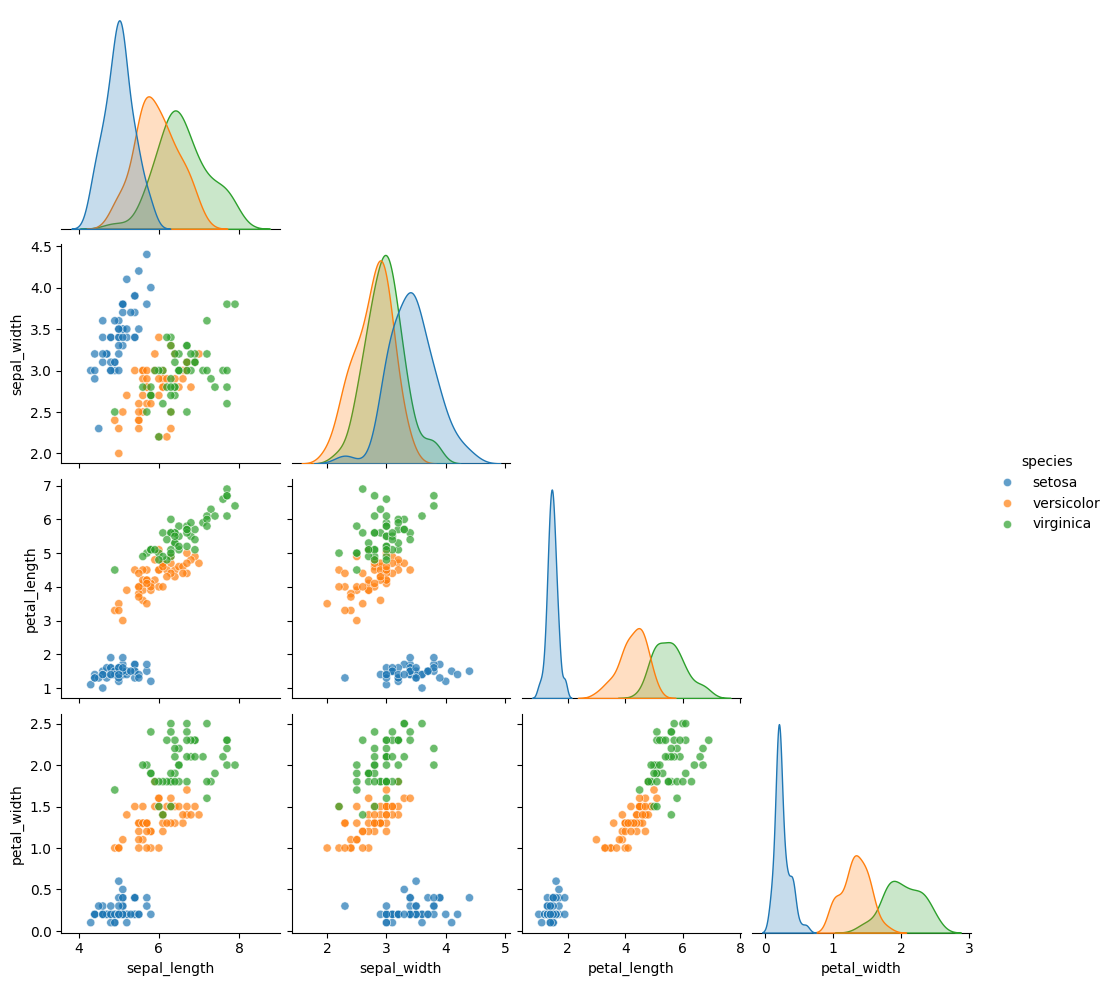

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset("iris")  # columns: sepal_length, sepal_width, petal_length, petal_width, species
sns.pairplot(df, hue="species", diag_kind="kde", corner=True, plot_kws=dict(alpha=0.7, s=35))
plt.show()

In [4]:
# Load the Iris dataset
iris = load_iris()                              # load the Iris dataset into a variable
X = iris.data                                   # feature data (sepal & petal length/width)
y = iris.target                                 # target labels (0=setosa, 1=versicolor, 2=virginica)



In [5]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)                                                # split data: 70% train, 30% test with equal class distribution



In [6]:
# Create and train the KNN model
knn = KNeighborsClassifier(n_neighbors=5)        # initialize KNN model with 5 neighbors
knn.fit(X_train, y_train)                        # train the KNN model using training data



,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [7]:
# Make predictions
y_pred = knn.predict(X_test)                     # predict class labels for the test data



In [8]:
# Evaluate model performance
print("Accuracy:", accuracy_score(y_test, y_pred))                    # print overall accuracy
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))      # print confusion matrix
print("\nClassification Report:\n",
      classification_report(y_test, y_pred, target_names=iris.target_names))  # print precision, recall, F1-score



Accuracy: 0.9777777777777777

Confusion Matrix:
 [[15  0  0]
 [ 0 15  0]
 [ 0  1 14]]

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.94      1.00      0.97        15
   virginica       1.00      0.93      0.97        15

    accuracy                           0.98        45
   macro avg       0.98      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



In [9]:
%matplotlib inline
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid", context="notebook")
# If you already have iris data:
# df = pd.read_csv("iris.csv")  # or however you loaded it
# Assume columns: sepal_length, sepal_width, petal_length, petal_width, species

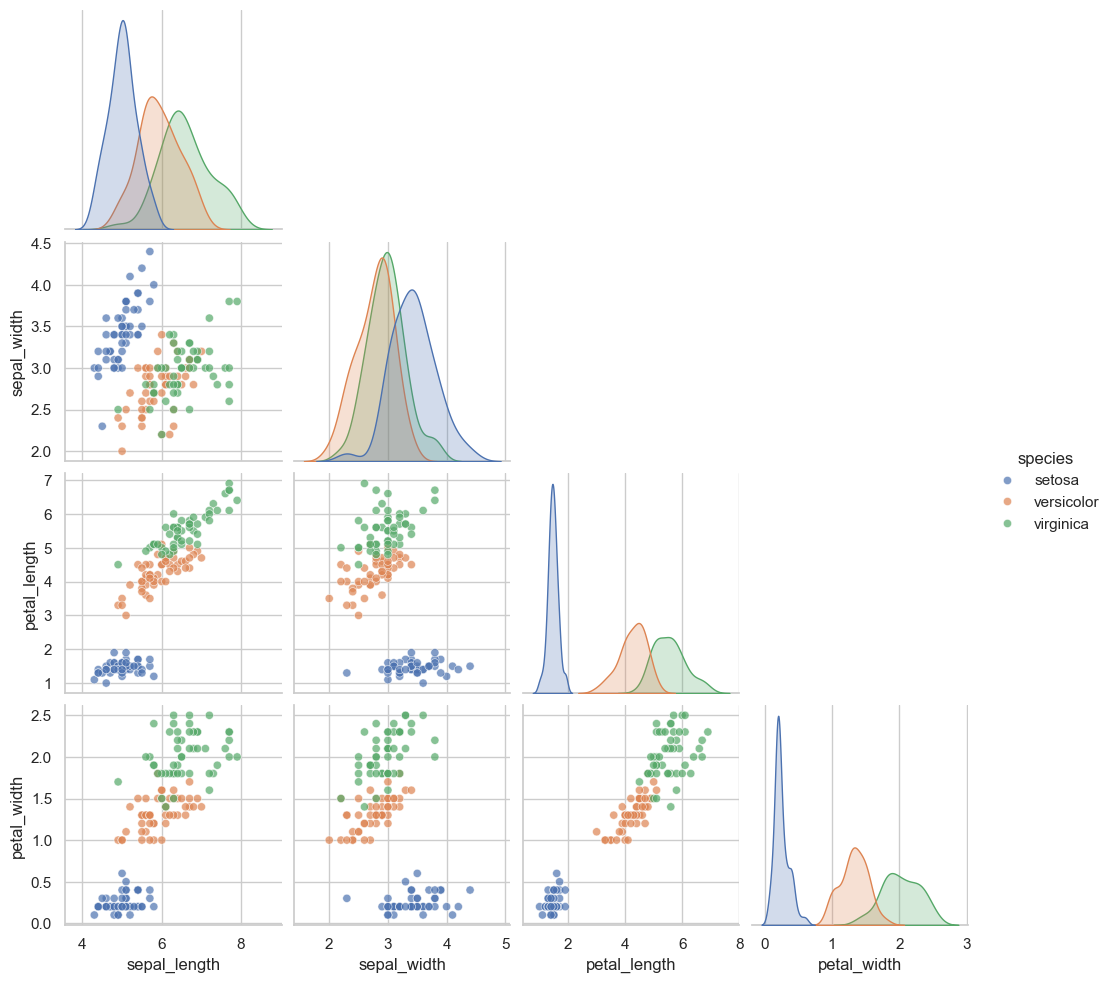

In [10]:
sns.pairplot(df, hue="species", diag_kind="kde", corner=True, plot_kws=dict(alpha=0.7, s=35))
plt.show()

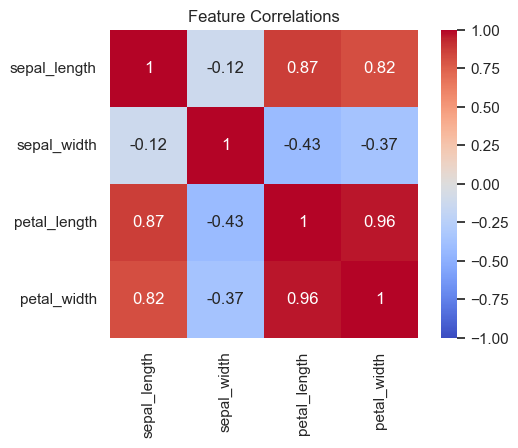

In [11]:
plt.figure(figsize=(6,4))
sns.heatmap(df.drop(columns=["species"]).corr(), annot=True, cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Feature Correlations")
plt.show()

C:\Users\Shahid\AppData\Local\Temp\ipykernel_4088\1300313178.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="species", palette="Set2")


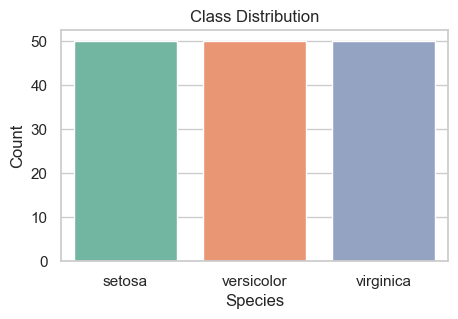

In [12]:
plt.figure(figsize=(5,3))
sns.countplot(data=df, x="species", palette="Set2")
plt.title("Class Distribution")
plt.xlabel("Species"); plt.ylabel("Count")
plt.show()

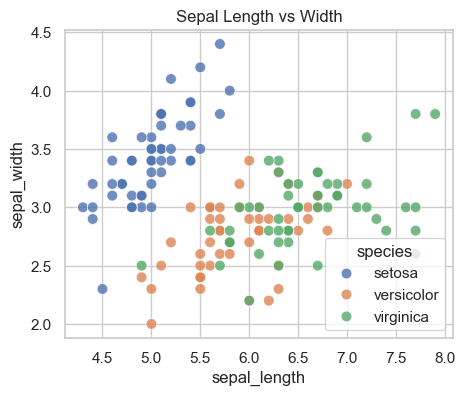

In [13]:
plt.figure(figsize=(5,4))
sns.scatterplot(data=df, x="sepal_length", y="sepal_width", hue="species", s=60, alpha=0.8)
plt.title("Sepal Length vs Width")
plt.show()

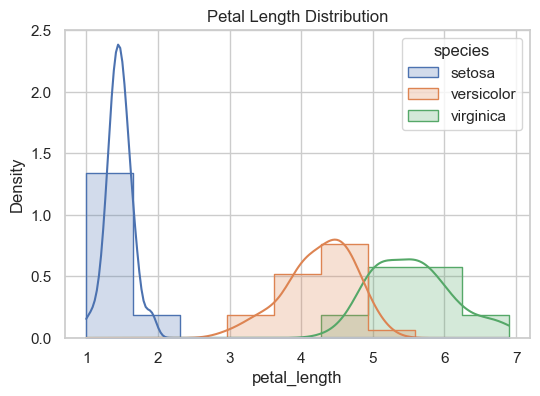

In [14]:
plt.figure(figsize=(6,4))
sns.histplot(data=df, x="petal_length", hue="species", kde=True, element="step", stat="density", common_norm=False)
plt.title("Petal Length Distribution")
plt.show()

In [16]:
# Test different k values and visualize accuracy
accuracies = []                                 # list to store accuracy for each k value
for k in range(1, 20):                          # try k values from 1 to 19
    model = KNeighborsClassifier(n_neighbors=k) # create KNN model for current k
    model.fit(X_train, y_train)                 # train the model
    acc = model.score(X_test, y_test)           # calculate accuracy for test data
    accuracies.append(acc)                      # store accuracy for this k



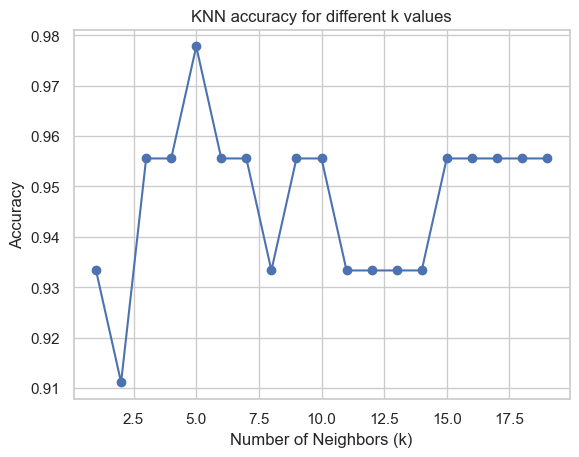

In [17]:
# Plot accuracy vs number of neighbors
plt.plot(range(1, 20), accuracies, marker='o')  # plot k vs accuracy curve
plt.xlabel("Number of Neighbors (k)")           # label for x-axis
plt.ylabel("Accuracy")                          # label for y-axis
plt.title("KNN accuracy for different k values")# title of the plot
plt.show()                                      # display the plot
